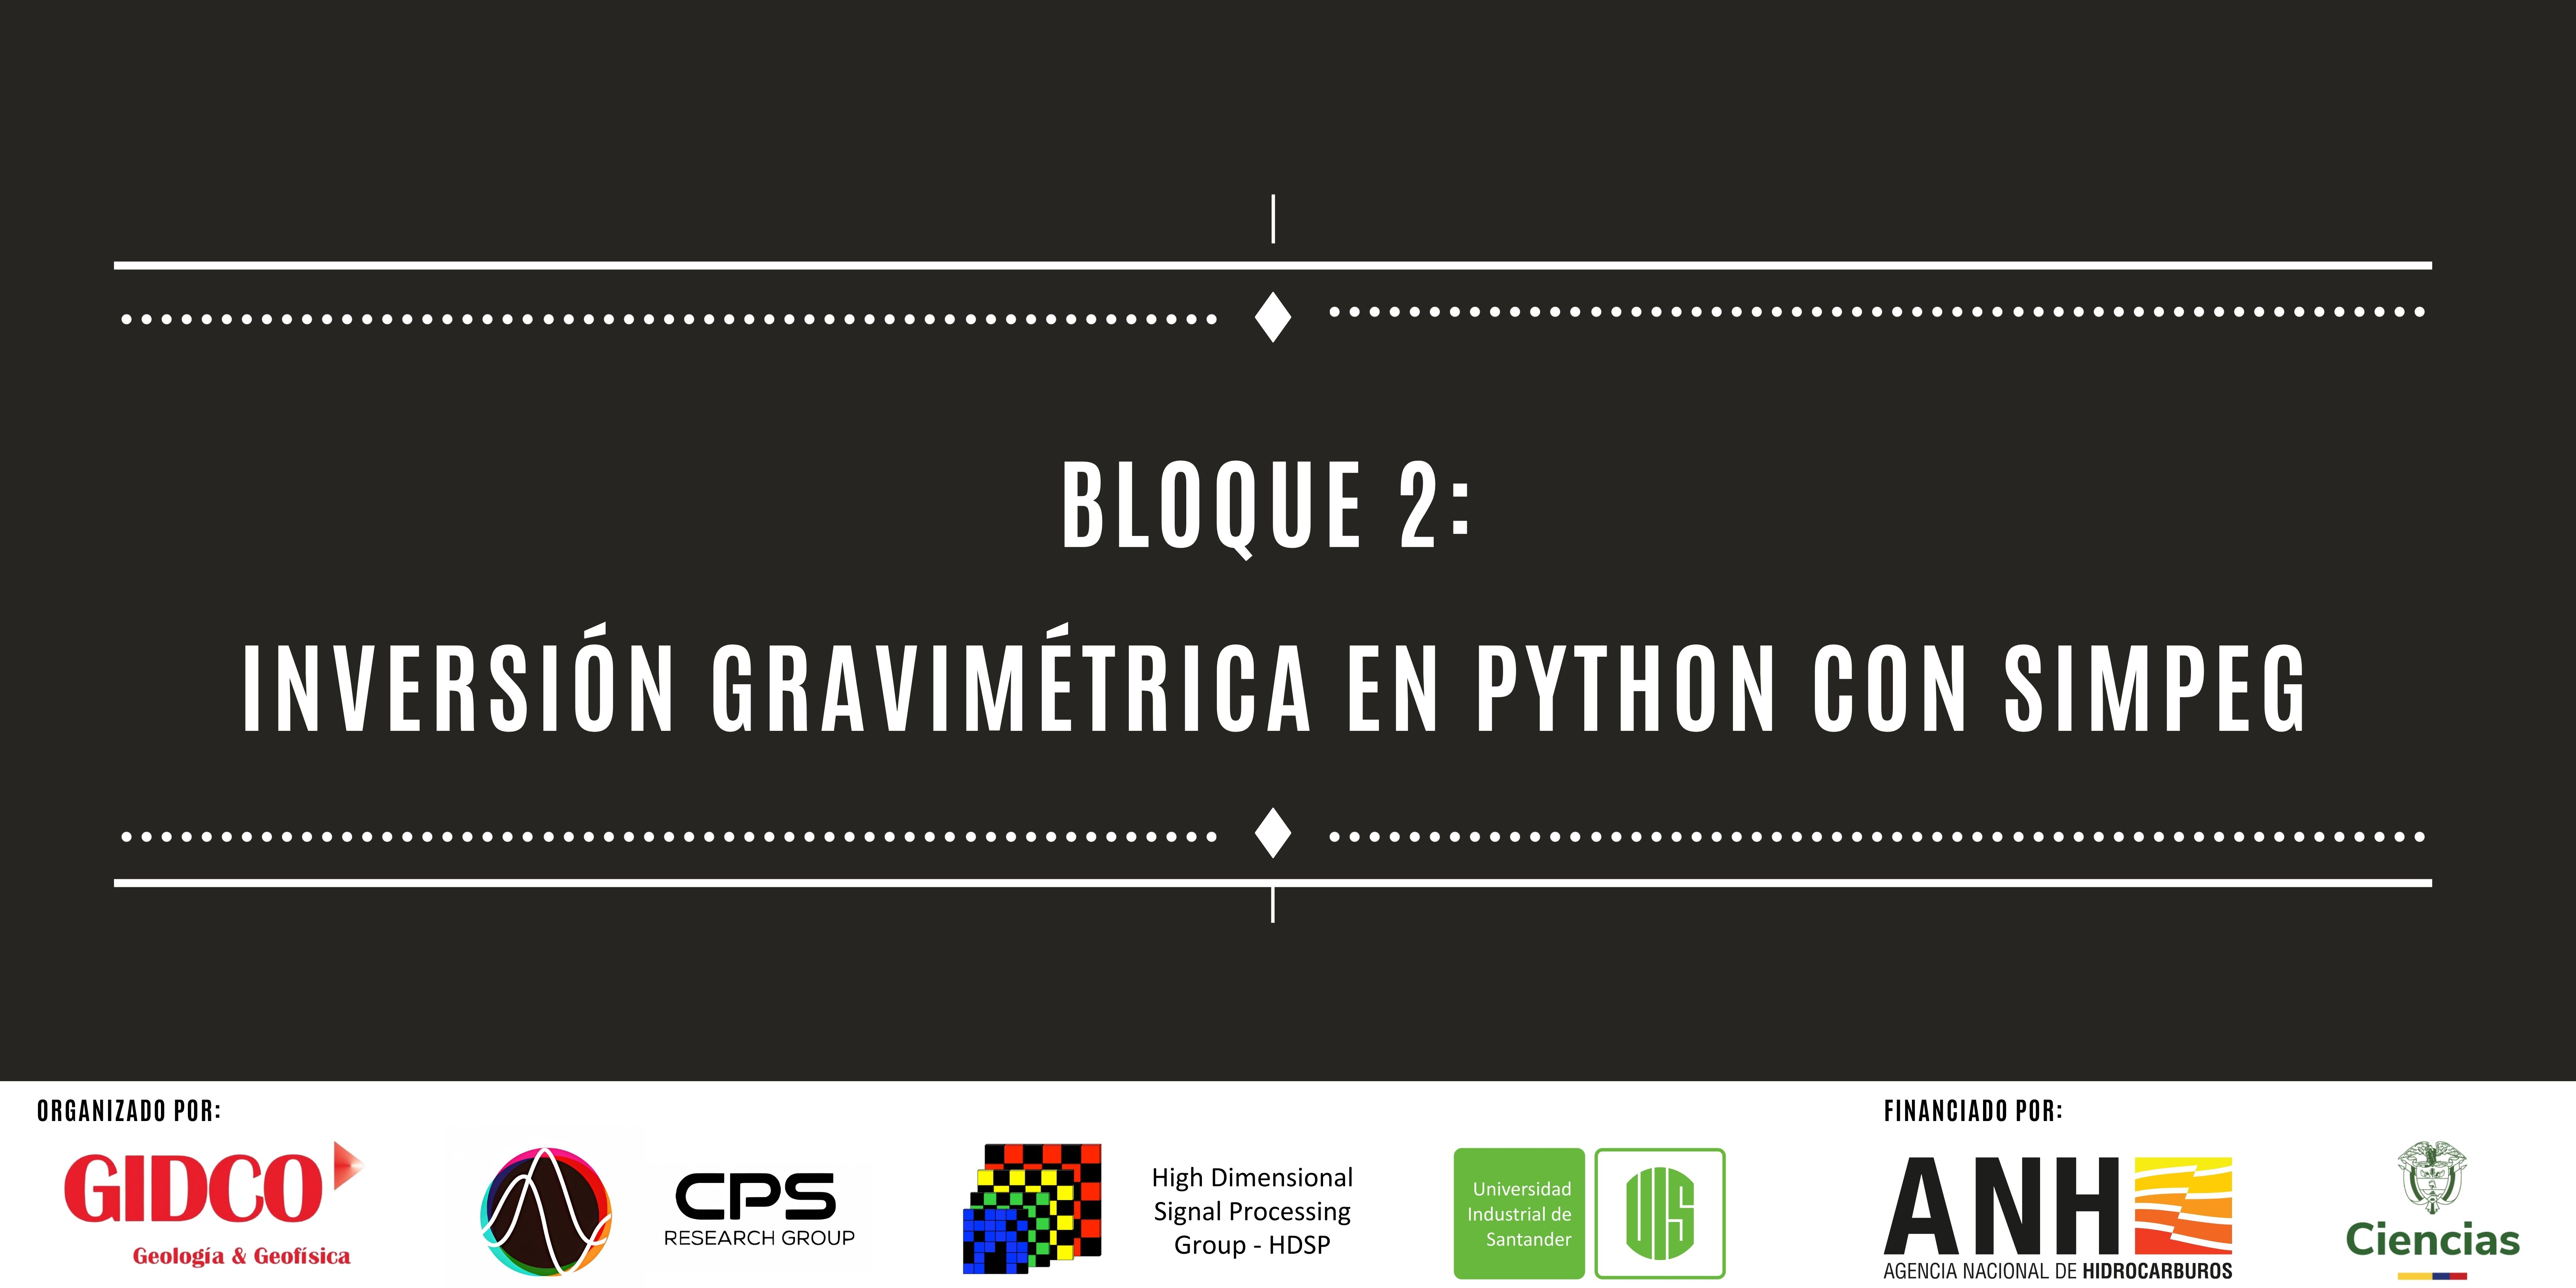

# Inversión gravimétrica 3D con **SimPEG** (caso real)

En este notebook construiremos un flujo completo para invertir datos de gravedad reales:

1. Cargar **topografía** y **anomalía gravimétrica**.
2. Definir incertidumbre \(\sigma\) y el *survey* de gravedad.
3. Construir una malla 3D y seleccionar **celdas activas** bajo la topografía.
4. Formular el problema inverso:  
   $
   \min_{\mathbf{m}}\; \phi_d(\mathbf{m}) + \beta\,\phi_m(\mathbf{m})
   $
5. Ejecutar la inversión y evaluar el ajuste (mapas + métricas).
6. Exportar el modelo a **VTI** para visualización 3D (ParaView/PyVista).

> Unidades: datos en **mGal**; modelo (contraste de densidad) en **g/cm³**.

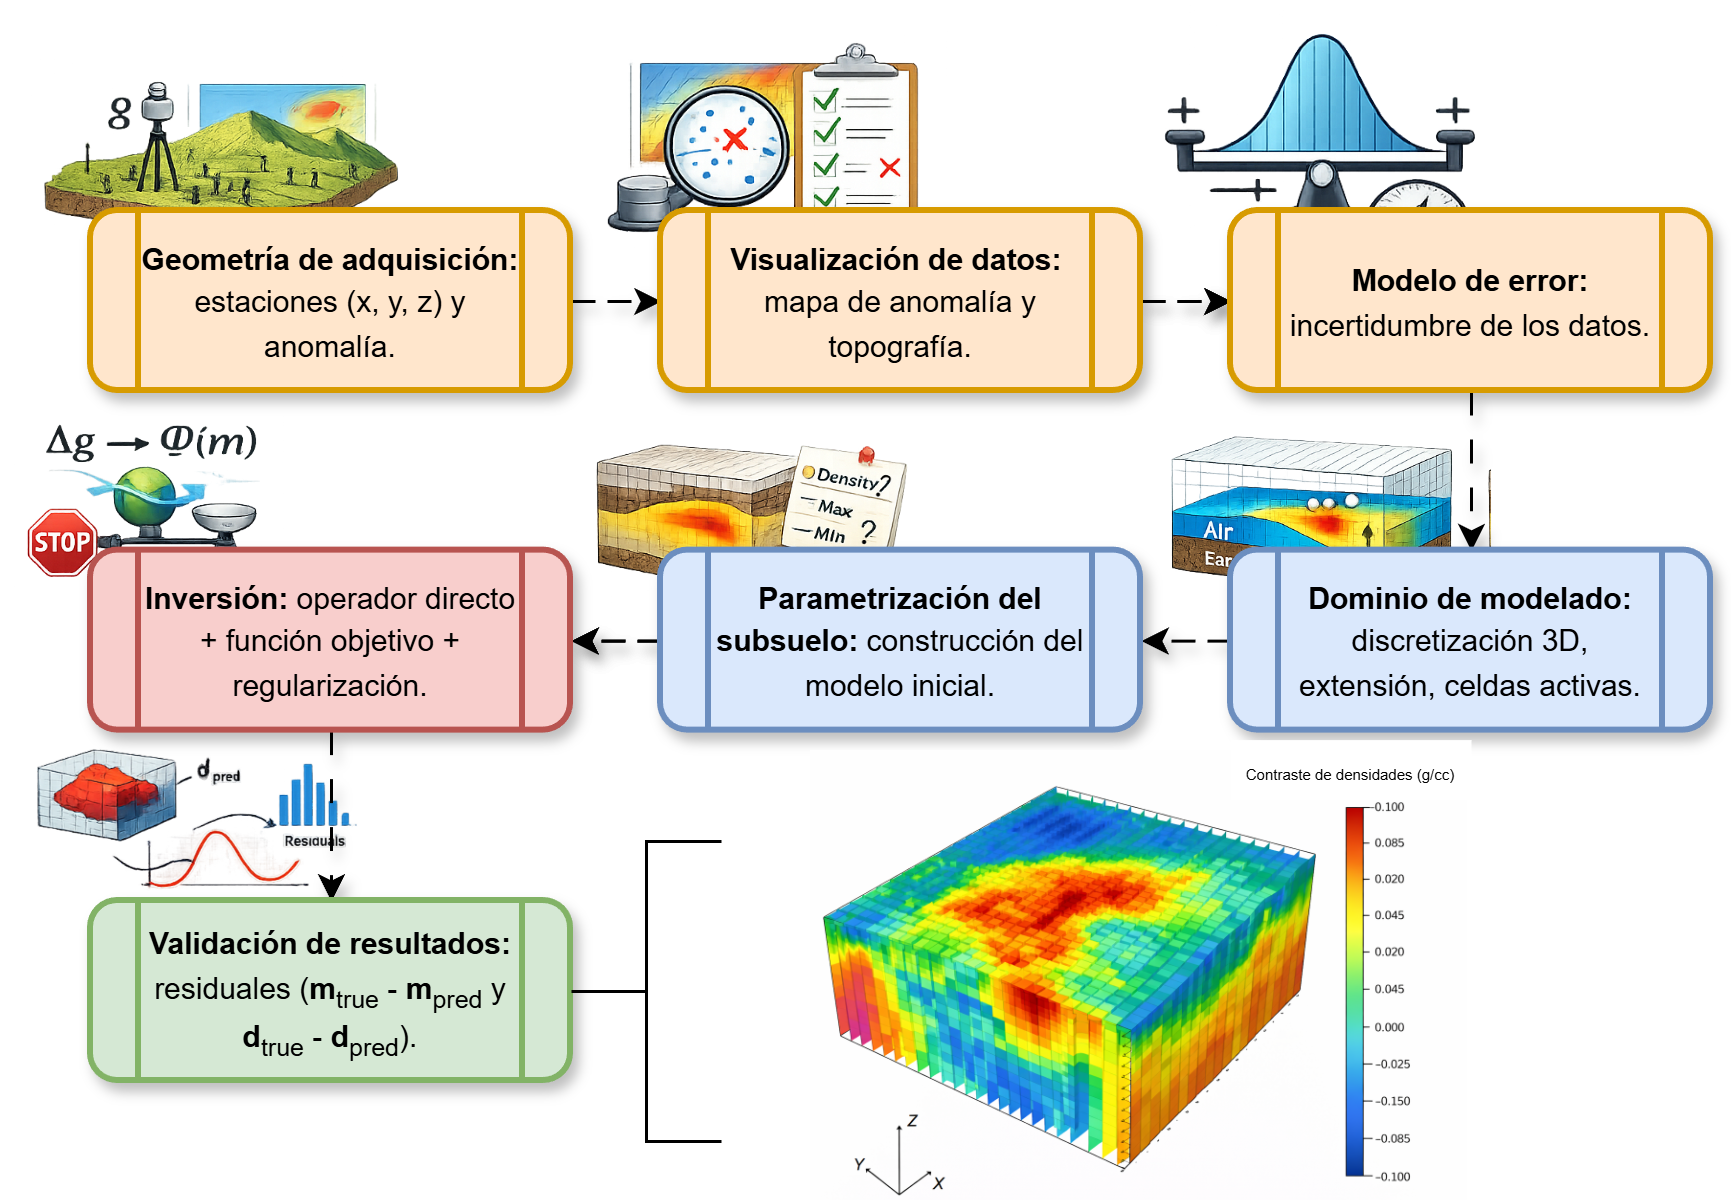

In [ ]:
!pip install simpeg
!pip -q install pyvista vtk

## 0. Entorno e importación de librerías

Aquí reunimos todo lo necesario para:

- **SimPEG**: inversión (misfit, regularización, optimización, directivas).
- **discretize**: malla 3D y utilidades de celdas activas.
- **matplotlib**: gráficos 2D para control de calidad.
- **pyvista**: exportación/visualización 3D del resultado (VTI).

También fijamos parámetros gráficos para que las figuras sean legibles en clase.

In [ ]:
# SimPEG functionality
from simpeg.utils import plot2Ddata
from simpeg import (
    maps, data, data_misfit, inverse_problem, regularization,
    optimization, directives, inversion, utils
)
from simpeg.potential_fields import gravity

# discretize functionality
from discretize import TensorMesh
from discretize.utils import active_from_xyz, mkvc

# Common Python functionality
import numpy as np
import pyvista as pv
import pandas as pd
from IPython.display import display
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams.update({"font.size": 14})
print("Librerías importadas correctamente.")

Librerías importadas correctamente.


## 1. Carga de insumos: topografía y datos de gravedad

Leemos dos archivos:

- `Topografia.txt`: puntos \((x,y,z)\) que describen la superficie.
- `Estaciones_AGCM_SGC_Gravimetria.txt`: estaciones \((x,y,z)\) y la anomalía observada.

En esta celda solo hacemos *sanity checks* rápidos (shapes) y separamos:

- `receiver_locations`: coordenadas de observación
- `dobs`: datos observados (mGal)

In [ ]:
# Archivos (puedes editar en Colab si los subes con esos nombres)
TOPO_FILE = "Topografia.txt"  #@param {type:"string"}
DATA_FILE = "Estaciones_AGCM_SGC_Gravimetria.txt"  #@param {type:"string"}

xyz_topo = np.loadtxt(TOPO_FILE)  # (Ntopo, 3)
print("Topografía:", xyz_topo.shape)

dobs_all = np.loadtxt(DATA_FILE)  # (Nobs, 4) -> x,y,z,data
print("Datos grav:", dobs_all.shape)

topografia = xyz_topo[:, 0:3]
receiver_locations = dobs_all[:, 0:3]
dobs = dobs_all[:, -1]   # mGal

x, y, z = receiver_locations[:, 0], receiver_locations[:, 1], receiver_locations[:, 2]

Topografía: (32400, 3)
Datos grav: (135, 4)


### Vista previa del formato (tablas)

Se imprime una tabla corta para verificar columnas y unidades:
- Topografía: `x, y, z`
- Datos: `x, y, z, dobs_mGal`

In [ ]:
# @title
df_topo = pd.DataFrame(xyz_topo, columns=["x", "y", "z"])
df_obs  = pd.DataFrame(dobs_all, columns=["x", "y", "z", "dobs_mGal"])

print("Topografía (primeras filas):")
display(df_topo.head(10))

print("Datos gravimétricos (primeras filas):")
display(df_obs.head(10))

Topografía (primeras filas):


,x,y,z
0,4730206.409,2048780.271,1888.0
1,4730271.603,2048780.177,1855.0
2,4730336.796,2048780.082,1839.0
3,4730401.990,2048779.987,1834.0
4,4730467.184,2048779.892,1828.0
5,4730532.378,2048779.797,1810.0
6,4730597.572,2048779.702,1779.0
7,4730662.766,2048779.607,1763.0
8,4730727.959,2048779.512,1758.0
9,4730793.153,2048779.417,1753.0


Datos gravimétricos (primeras filas):


,x,y,z,dobs_mGal
0,4732883.463,2049345.170,1802.569,-0.89
1,4740260.711,2051069.569,2014.366,13.77
2,4733205.458,2057405.449,2127.088,-5.59
3,4733091.517,2056492.891,1954.450,-3.48
4,4733001.529,2056965.559,1981.408,-4.60
5,4732903.467,2057445.212,1990.299,-4.91
6,4732884.868,2057954.180,2023.524,-5.13
7,4733015.573,2056311.956,1952.983,-2.28
8,4732834.901,2056687.861,1964.500,-3.07
9,4732722.860,2057148.520,1996.752,-3.78


## 2. Visualizar: datos y topografía

Antes de invertir, siempre verificamos:

- patrón espacial de la anomalía (tendencias, outliers, vacíos),
- coherencia espacial con el área de topografía,
- rango de valores (para decidir escalas y $\sigma$).

Mostramos dos mapas con barras de color independientes:
1) anomalía gravimétrica
2) elevación topográfica.

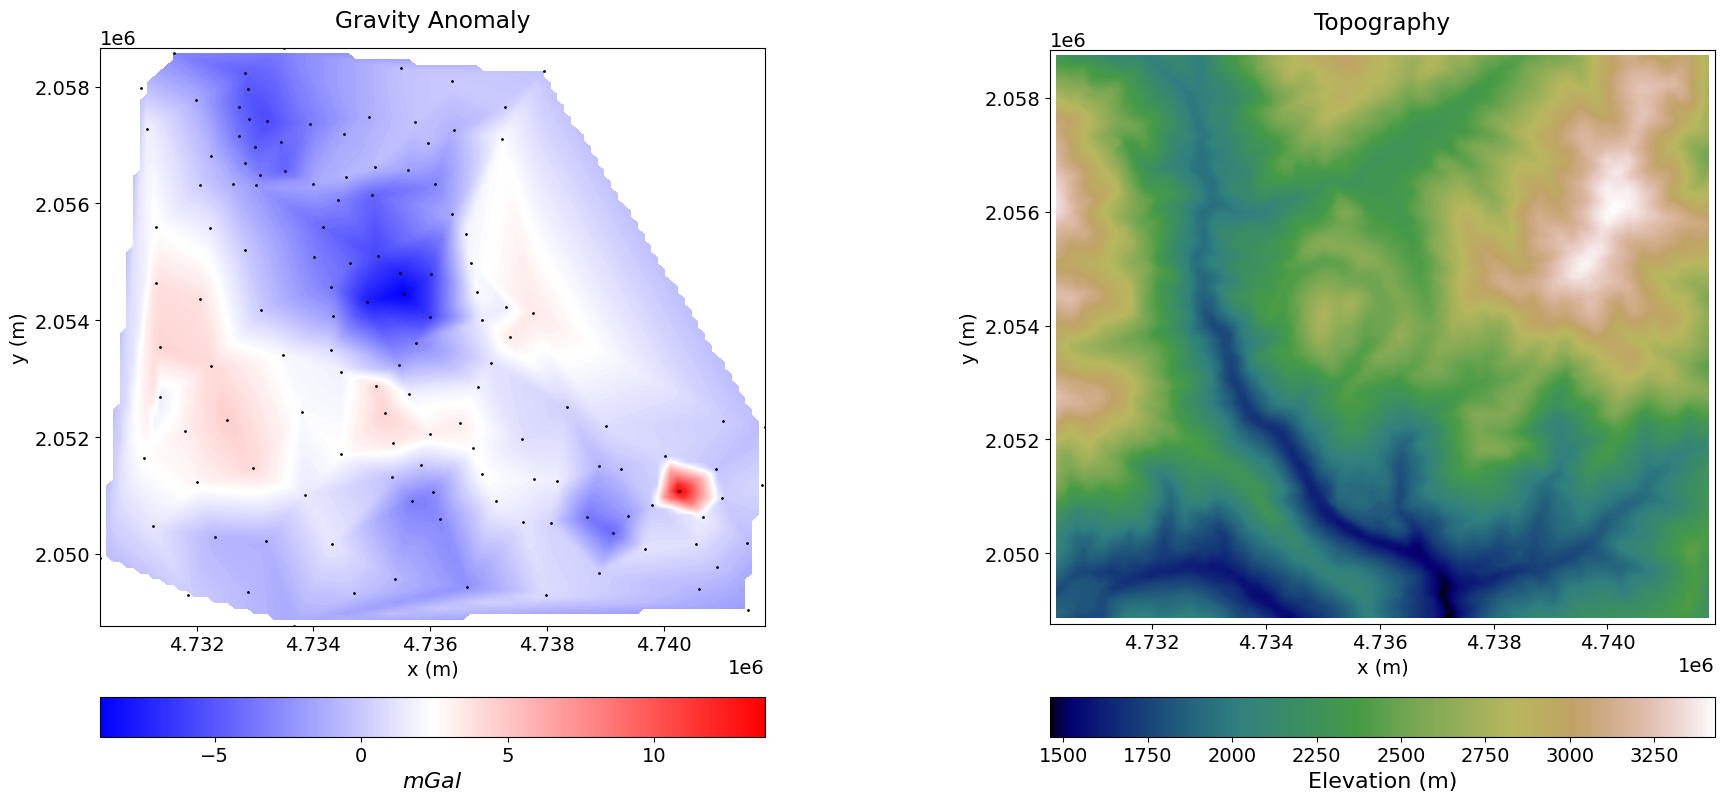

In [ ]:
NCONTOUR_DATA = 200  #@param {type:"integer", min:5, max:200, step:5}
NCONTOUR_TOPO = 200  #@param {type:"integer", min:5, max:200, step:5}

fig = plt.figure(figsize=(19, 10))

# --- 1) Gravity anomaly ---
ax1 = fig.add_axes([0.05, 0.35, 0.35, 0.6])
plot2Ddata(
    receiver_locations,
    dobs,
    ax=ax1,
    dataloc=True,
    ncontour=NCONTOUR_DATA,
    contourOpts={"cmap": "bwr"},
)
ax1.set_title("Gravity Anomaly", pad=15)
ax1.set_xlabel("x (m)")
ax1.set_ylabel("y (m)")

cx1 = fig.add_axes([0.05, 0.25, 0.35, 0.04])
norm1 = mpl.colors.Normalize(vmin=np.min(dobs), vmax=np.max(dobs))
cbar1 = mpl.colorbar.ColorbarBase(cx1, norm=norm1, orientation="horizontal", cmap=mpl.cm.bwr)
cbar1.set_label("$mGal$", size=16)

# --- 2) Topography ---
ax2 = fig.add_axes([0.55, 0.35, 0.35, 0.6])
plot2Ddata(
    xyz_topo[:, 0:2],
    xyz_topo[:, -1],
    ax=ax2,
    dataloc=False,
    ncontour=NCONTOUR_TOPO,
    contourOpts={"cmap": "gist_earth"},
)
ax2.set_title("Topography", pad=15)
ax2.set_xlabel("x (m)")
ax2.set_ylabel("y (m)")

cx2 = fig.add_axes([0.55, 0.25, 0.35, 0.04])
norm2 = mpl.colors.Normalize(vmin=np.min(xyz_topo[:, -1]), vmax=np.max(xyz_topo[:, -1]))
cbar2 = mpl.colorbar.ColorbarBase(cx2, norm=norm2, orientation="horizontal", cmap=mpl.cm.gist_earth)
cbar2.set_label("Elevation (m)", size=16)

plt.show()

## 3. Incertidumbres y pesos en datos (notación tipo GIFtools)

Misfit ponderado:
$$
\phi_d(\mathbf{m})=
\sum_{i=1}^{N}\left(\frac{F(\mathbf{m})_i-d_i}{\varepsilon_i}\right)^2
=
\left\|\mathbf{W}_d\left(\mathbf{d}-\mathbf{F}(\mathbf{m})\right)\right\|_2^2,
\qquad
\mathbf{W}_d=\mathrm{diag}(\varepsilon_i^{-1})
$$

Modelo típico:
$$
\varepsilon_i=\varepsilon_{\text{floor}}+C_\%|d_i|
$$

In [ ]:
rel_unc = 0.02   #@param {type:"number", min:0, max:0.5, step:0.005}
floor_unc = 0.05 #@param {type:"number", min:0, max:5.0, step:0.01}

sigma = floor_unc + rel_unc * np.abs(dobs)

print(
    f"Unc stats -> floor={floor_unc:.3f} mGal, rel={100*rel_unc:.1f}%, "
    f"median σ={np.median(sigma):.3f} mGal"
)

Unc stats -> floor=0.050 mGal, rel=2.0%, median σ=0.083 mGal


## 4. Definición del *survey* y objeto `Data`

Creamos el survey de gravedad (componente **gz**) y empaquetamos:

- datos observados,
- incertidumbre $\sigma$,
- geometría (receptores).

> Nota importante (convención de signo): en este notebook se define `dobs=-dobs` dentro del objeto `Data`.  
Esto es válido si tu convención de medición y la del forward están invertidas, pero conviene mantenerlo **consistente** en todo el flujo (predicción, residuales, métricas).


In [ ]:
# Convención de signo dentro del objeto Data
FLIP_SIGN_IN_DATAOBJECT = True  #@param {type:"boolean"}

receiver = gravity.receivers.Point(receiver_locations, components="gz")
survey = gravity.survey.Survey(gravity.sources.SourceField(receiver_list=[receiver]))

dobs_for_dataobj = -dobs if FLIP_SIGN_IN_DATAOBJECT else dobs
data_object = data.Data(survey, dobs=dobs_for_dataobj, standard_deviation=sigma)

## 5. Malla 3D (TensorMesh): discretización del subsuelo

Definimos una malla tensorial regular:

- `dx, dy, dz`: tamaño de celda
- `ncx, ncy, ncz`: número de celdas por eje
- `x0`: origen (esquina inferior) en coordenadas reales

Esta malla define el espacio donde se estimará el contraste de densidad.


In [ ]:
dx = 260  #@param {type:"number", min:1, max:5000, step:1}
dy = 275  #@param {type:"number", min:1, max:5000, step:1}
dz = 225  #@param {type:"number", min:1, max:5000, step:1}

ncx = 50  #@param {type:"integer", min:1, max:500, step:1}
ncy = 40  #@param {type:"integer", min:1, max:500, step:1}
ncz = 45  #@param {type:"integer", min:1, max:500, step:1}

x0_x = 4729500  #@param {type:"number"}
x0_y = 2048000  #@param {type:"number"}
x0_z = -6000    #@param {type:"number"}

hx = [(dx, ncx)]
hy = [(dy, ncy)]
hz = [(dz, ncz)]

mesh = TensorMesh([hx, hy, hz], x0=[x0_x, x0_y, x0_z])
print("Mesh shape cells:", mesh.shape_cells)
print("nC total:", mesh.nC)

Mesh shape cells: (50, 40, 45)
nC total: 90000


## 6. QC de malla: cobertura de estaciones y geometría

Antes de invertir, verificamos:

- que la malla cubra el dominio de estaciones,
- que el origen \(x0\) y las dimensiones sean coherentes,
- que no queden estaciones fuera del dominio.

Mostramos vistas simples (3D/XY/XZ) con puntos de estaciones sobre la malla.


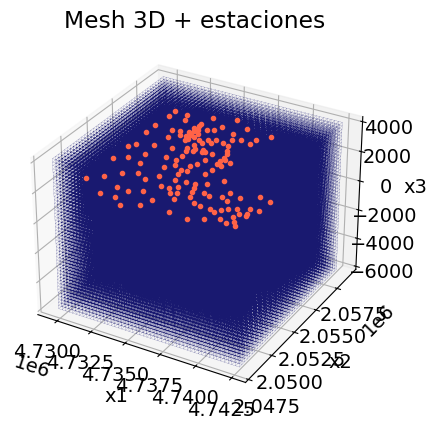

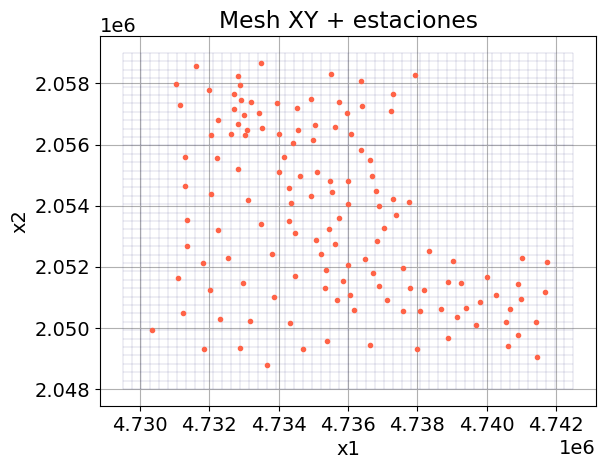

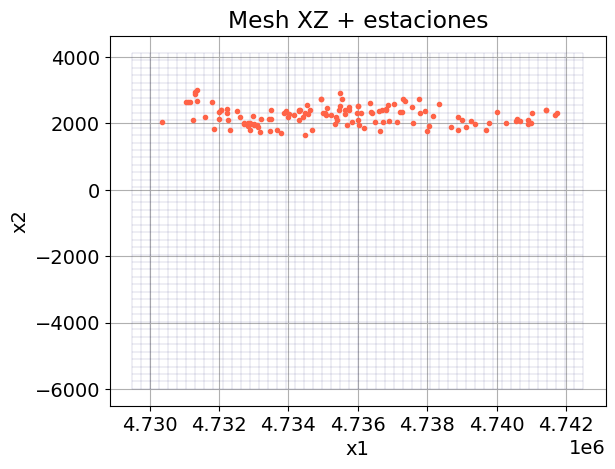

In [ ]:
# 3D grid (simple)
mesh.plot_grid(color="midnightblue", linewidth=0.1)
plt.plot(x, y, z, ".", color="tomato")
plt.title("Mesh 3D + estaciones")
plt.show()

# XY
meshes_xy = TensorMesh([hx, hy], x0=[x0_x, x0_y])
meshes_xy.plot_grid(color="midnightblue", linewidth=0.1)
plt.plot(x, y, ".", color="tomato")
plt.title("Mesh XY + estaciones")
plt.show()

# XZ
meshes_xz = TensorMesh([hx, hz], x0=[x0_x, x0_z])
meshes_xz.plot_grid(color="midnightblue", linewidth=0.1)
plt.plot(x, z, ".", color="tomato")
plt.title("Mesh XZ + estaciones")
plt.show()

## 7. Celdas activas, mapeos y modelo inicial

La inversión solo se realiza en celdas **activas** (bajo topografía).  
Esto evita estimar propiedades “en el aire” y mejora la interpretabilidad.

En esta celda definimos:

- `active_tensor_cells`: máscara booleana de celdas activas
- `tensor_model_map`: mapeo (aquí, identidad: un parámetro por celda activa)
- `starting_tensor_model`: modelo inicial (aquí un gradiente con profundidad)
- `reference_tensor_model`: referencia para la regularización
- `tensor_plotting_map`: para graficar ignorando celdas inactivas


In [ ]:
active_tensor_cells = active_from_xyz(mesh, topografia)
n_tensor_active = int(active_tensor_cells.sum())
print("Active cells:", n_tensor_active)

tensor_model_map = maps.IdentityMap(nP=n_tensor_active)

# Starting model: gradiente con z (editable)
START_A = 0.3   #@param {type:"number", min:-5, max:5, step:0.05}
START_B = -0.6  #@param {type:"number", min:-5, max:5, step:0.05}

active_cells_centers = mesh.cell_centers[active_tensor_cells]
z_active = active_cells_centers[:, 2]
z_normalized = (z_active - z_active.min()) / (z_active.max() - z_active.min())

starting_tensor_model = START_A + START_B * z_normalized
reference_tensor_model = np.zeros_like(starting_tensor_model)

tensor_plotting_map = maps.InjectActiveCells(mesh, active_tensor_cells, np.nan)

Active cells: 74727


### Corte 2D: topografía + malla + activas/inactivas (qué se invierte y qué no)

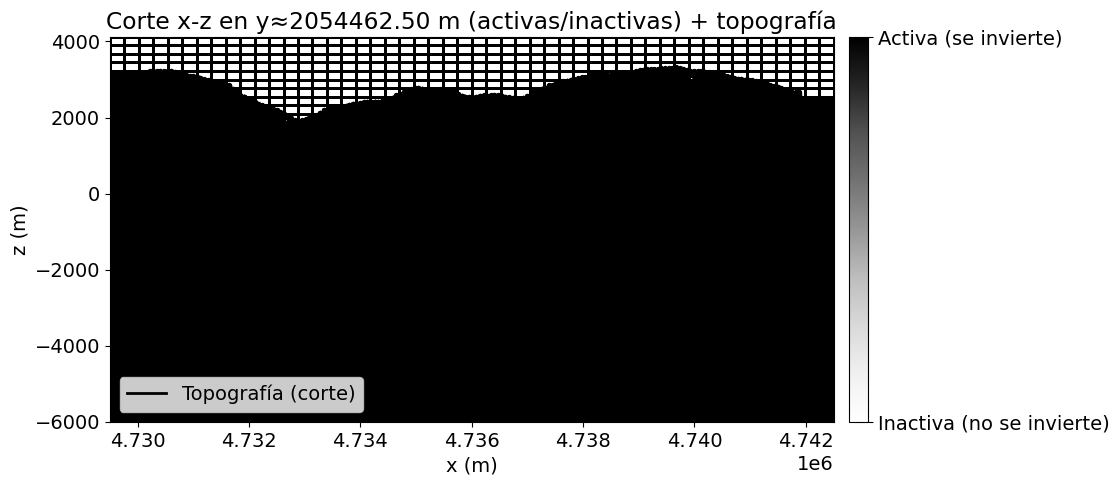

In [ ]:
SLICE_Y_LOC = 2054572  #@param {type:"number"}

# y real del corte (centro de celda más cercano)
y_centers = mesh.cell_centers[:, 1]
y0 = y_centers[np.argmin(np.abs(y_centers - SLICE_Y_LOC))]

# campo binario: 1 activa, 0 inactiva (en toda la malla)
active_full = np.zeros(mesh.nC)
active_full[active_tensor_cells] = 1.0

fig, ax = plt.subplots(1, 1, figsize=(10, 5))

out = mesh.plot_slice(
    active_full,
    normal="Y",
    slice_loc=y0,
    ax=ax,
    grid=True,
    pcolor_opts={"cmap": "Greys", "vmin": 0, "vmax": 1},
)
cbar = plt.colorbar(out[0], ax=ax, fraction=0.046, pad=0.02)
cbar.set_ticks([0, 1])
cbar.set_ticklabels(["Inactiva (no se invierte)", "Activa (se invierte)"])

# Topografía cercana al corte (perfil aproximado en x-z)
tol = max(mesh.h[1].min(), 5.0)
mask_topo = np.abs(topografia[:, 1] - y0) < tol
topo_cut = topografia[mask_topo]

if topo_cut.shape[0] > 5:
    topo_cut = topo_cut[np.argsort(topo_cut[:, 0])]
    ax.plot(topo_cut[:, 0], topo_cut[:, 2], "k-", lw=2, label="Topografía (corte)")
    ax.scatter(topo_cut[:, 0], topo_cut[:, 2], s=8, c="k")
    ax.legend(loc="lower left")
else:
    ax.text(
        0.02, 0.95,
        "Pocos puntos de topografía en este corte.\nPrueba otro SLICE_Y_LOC.",
        transform=ax.transAxes, va="top"
    )

ax.set_title(f"Corte x-z en y≈{y0:.2f} m (activas/inactivas) + topografía")
ax.set_xlabel("x (m)")
ax.set_ylabel("z (m)")
plt.show()

## 8. Visualización del modelo inicial (slice)

Antes de correr la inversión, inspeccionamos el **modelo inicial** en un corte 2D.

Objetivo:
- confirmar rango y patrón del modelo inicial,
- verificar el plano y la ubicación del *slice*,
- detectar escalas absurdas (que puedan dificultar convergencia).

> Tip: el modelo inicial puede ser cero, constante o con tendencia suave; lo importante es que sea **razonable**.


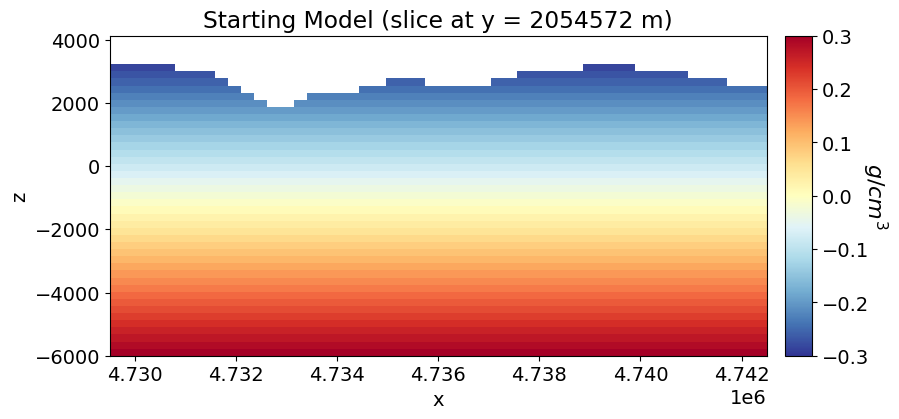

In [ ]:
slice_loc = 2054572  #@param {type:"number"}
slice_normal = "y"   #@param ["x","y","z"]

fig = plt.figure(figsize=(9, 4))
ax1 = fig.add_axes([0.1, 0.1, 0.73, 0.8])

norm = mpl.colors.Normalize(vmin=np.min(starting_tensor_model), vmax=np.max(starting_tensor_model))

mesh.plot_slice(
    tensor_plotting_map * starting_tensor_model,
    normal=slice_normal,
    ax=ax1,
    slice_loc=slice_loc,
    grid=False,
    pcolor_opts={"cmap": mpl.cm.RdYlBu_r, "norm": norm},
)

ax1.set_title(f"Starting Model (slice at {slice_normal} = {slice_loc} m)")

ax2 = fig.add_axes([0.85, 0.1, 0.03, 0.8])
cbar = mpl.colorbar.ColorbarBase(ax2, norm=norm, orientation="vertical", cmap=mpl.cm.RdYlBu_r)
cbar.set_label("$g/cm^3$", rotation=270, labelpad=15, size=16)

plt.show()

## 9. Operador directo de gravimetría (gz) + Forward y misfit

Operador directo (forma continua):

$$
d_i = g_z(\mathbf{r}_i) =
G \int_V \Delta\rho(\mathbf{r}')
\frac{(z_i - z')}{\|\mathbf{r}_i - \mathbf{r}'\|^3} \, dV'
$$

Discretización:

$$
\mathbf{d} = \mathbf{G}\mathbf{m}
$$

`Simulation3DIntegral` implementa $\mathbf{m} \mapsto \mathbf{d}_{pred}$ y `L2DataMisfit` implementa $\phi_d$.

In [ ]:
simulation_L2 = gravity.simulation.Simulation3DIntegral(
    survey=survey,
    mesh=mesh,
    rhoMap=tensor_model_map,
    active_cells=active_tensor_cells,
    store_sensitivities="ram",
)

dmis_L2 = data_misfit.L2DataMisfit(data=data_object, simulation=simulation_L2)

## 10. Regularización WLS + depth weighting (notación)

Función objetivo:
$$
\phi(\mathbf{m})=\phi_d(\mathbf{m})+\beta\,\phi_m(\mathbf{m})
$$

Forma típica (Tikhonov con pesos):
$$
\begin{split}
\phi_m(\mathbf{m})=&\
\alpha_s \|\mathbf{W_s}\mathbf{R}_s(\mathbf{m}-\mathbf{m}_{ref})\|_2^2
+ \alpha_x \|\mathbf{W_x}\mathbf{R}_x\mathbf{G}_x(\mathbf{m}-\mathbf{m}_{ref})\|_2^2\\
&+ \alpha_y \|\mathbf{W_y}\mathbf{R}_y\mathbf{G}_y(\mathbf{m}-\mathbf{m}_{ref})\|_2^2
+ \alpha_z \|\mathbf{W_z}\mathbf{R}_z\mathbf{G}_z(\mathbf{m}-\mathbf{m}_{ref})\|_2^2
\end{split}
$$

En el código:
- `WeightedLeastSquares(..., alpha_s, alpha_x, alpha_y, alpha_z)`
- `weights={"cell_weights": wr_Depth}` actúa como un peso espacial por celda (depth weighting)

In [ ]:
DEPTH_EXPONENT = 3   #@param {type:"integer", min:0, max:6, step:1}
DEPTH_THRESHOLD = 5  #@param {type:"number", min:0, max:1e6, step:1}
DEPTH_V = 2          #@param {type:"number", min:0, max:1e6, step:1}

alpha_s = 1e-4  #@param {type:"number"}
alpha_x = 1.0   #@param {type:"number"}
alpha_y = 1.0   #@param {type:"number"}
alpha_z = 10.0  #@param {type:"number"}

wr_Depth = utils.depth_weighting(
    mesh, receiver_locations, active_cells=active_tensor_cells,
    exponent=DEPTH_EXPONENT, threshold=DEPTH_THRESHOLD, v=DEPTH_V
)
wr_Depth = wr_Depth**2

reg_L2 = regularization.WeightedLeastSquares(
    mesh,
    active_cells=active_tensor_cells,
    mapping=tensor_model_map,
    alpha_s=alpha_s,
    alpha_x=alpha_x,
    alpha_y=alpha_y,
    alpha_z=alpha_z,
    reference_model=reference_tensor_model,
    reference_model_in_smooth=True,
    weights={"cell_weights": wr_Depth},
)

## 11. Optimizador y directivas de inversión

Definimos cómo se resuelve el problema:

- Optimizador `ProjectedGNCG`: Gauss-Newton proyectado con límites (lower/upper).
- Directivas:
  - `UpdateSensitivityWeights`: pesos por sensibilidad para estabilizar amplitudes.
  - `BetaEstimate_ByEig` + `BetaSchedule`: inicialización y enfriamiento de \(\beta\).
  - `TargetMisfit`: detener cuando el ajuste es consistente con el ruido ($\chi^2$ ~ 1).
  - `SaveOutputDictEveryIteration`: guardar historial para análisis posterior.

Estas piezas controlan convergencia, estabilidad y trazabilidad del resultado.

### 11.1 Optimizador (ProjectedGNCG) y problema inverso

In [ ]:
maxIter = 20    #@param {type:"integer", min:1, max:200, step:1}
maxIterLS = 60  #@param {type:"integer", min:1, max:500, step:1}
maxIterCG = 70  #@param {type:"integer", min:1, max:1000, step:1}
tolCG = 1e-3    #@param {type:"number"}

lower = -0.4    #@param {type:"number"}
upper = 0.5     #@param {type:"number"}

opt_L2 = optimization.ProjectedGNCG(
    maxIter=maxIter,
    maxIterLS=maxIterLS,
    maxIterCG=maxIterCG,
    tolCG=tolCG,
    lower=lower,
    upper=upper,
)

inv_prob_L2 = inverse_problem.BaseInvProblem(dmis_L2, reg_L2, opt_L2)

/usr/local/lib/python3.12/dist-packages/simpeg/optimization.py:1535: FutureWarning: InexactCG.tolCG has been deprecated, please use InexactCG.cg_atol. It will be removed in version 0.26.0 of SimPEG.
  self.tolCG = val
/usr/local/lib/python3.12/dist-packages/simpeg/optimization.py:1061: FutureWarning: InexactCG.maxIterCG has been deprecated, please use InexactCG.cg_maxiter. It will be removed in version 0.26.0 of SimPEG.
  self.maxIterCG = val


### 11.2 Directivas (β, agenda de β, misfit objetivo, pesos de sensibilidad)

In [ ]:
beta0_ratio = 1.0      #@param {type:"number", min:1e-3, max:100, step:0.1}
coolingFactor = 2.0    #@param {type:"number", min:1.0, max:10.0, step:0.1}
coolingRate = 1        #@param {type:"integer", min:1, max:10, step:1}
chifact = 1.0          #@param {type:"number", min:0.1, max:10.0, step:0.1}

SENS_THRESH = 1e-12    #@param {type:"number"}

save_iteration = directives.SaveOutputDictEveryIteration()
save_iteration.outDict = {}

sensitivity_weights = directives.UpdateSensitivityWeights(
    every_iteration=True,
    threshold_value=SENS_THRESH,
    threshold_method="amplitude",
    normalization_method="maximum",
)

update_jacobi = directives.UpdatePreconditioner(update_every_iteration=True)
starting_beta = directives.BetaEstimate_ByEig(beta0_ratio=beta0_ratio)
beta_schedule = directives.BetaSchedule(coolingFactor=coolingFactor, coolingRate=coolingRate)
target_misfit = directives.TargetMisfit(chifact=chifact)

directives_list_L2 = [
    sensitivity_weights,
    update_jacobi,
    starting_beta,
    beta_schedule,
    target_misfit,
    save_iteration,
]

## 12. Ejecutar la inversión

Corremos la inversión a partir del modelo inicial:

- en cada iteración se evalúa el forward,
- se actualiza el modelo $\mathbf{m}$,
- se ajusta $\beta$ según las directivas,
- y se aplican los pesos/suavidad definidos.

Resultado: `recovered_tensor_model` (contraste de densidad en celdas activas).

In [ ]:
inv_L2 = inversion.BaseInversion(inv_prob_L2, directives_list_L2)
recovered_tensor_model = inv_L2.run(starting_tensor_model)


Running inversion with SimPEG v0.25.2


INFO: Directive TargetMisfit: Target data misfit is 135.0
INFO:SimPEG:Directive TargetMisfit: Target data misfit is 135.0


================================================= Projected GNCG =================================================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS   iter_CG   CG |Ax-b|/|b|  CG |Ax-b|   Comment   
-----------------------------------------------------------------------------------------------------------------
   0  2.19e+01  4.28e+05  6.02e+01  4.29e+05                         0           inf          inf                
   1  2.19e+01  3.65e+03  9.01e+00  3.85e+03    1.25e+02      0      70       4.78e-03     5.72e+02              
   2  1.10e+01  1.58e+03  8.14e+00  1.67e+03    1.08e+02      0      70       9.76e-02     6.98e+02              
   3  5.48e+00  1.34e+03  8.38e+00  1.39e+03    1.41e+02      1      70       1.19e-01     5.35e+02              
   4  2.74e+00  9.34e+02  9.37e+00  9.60e+02    1.40e+02      2      70       1.32e-01     6.06e+02              
   5  1.37e+00  9.33e+02  9.38e+00  9.46e+02    1.16e+02      8      70       8.96e-02 

## 13. Modelo recuperado: inspección en corte 2D

Graficamos el resultado en el mismo tipo de *slice* para:

- identificar anomalías principales,
- revisar amplitudes y coherencia espacial,
- verificar que el modelo no quede dominado por bordes o ruido.

> En clase: esta figura suele ser la “primera lectura” geológica del resultado.


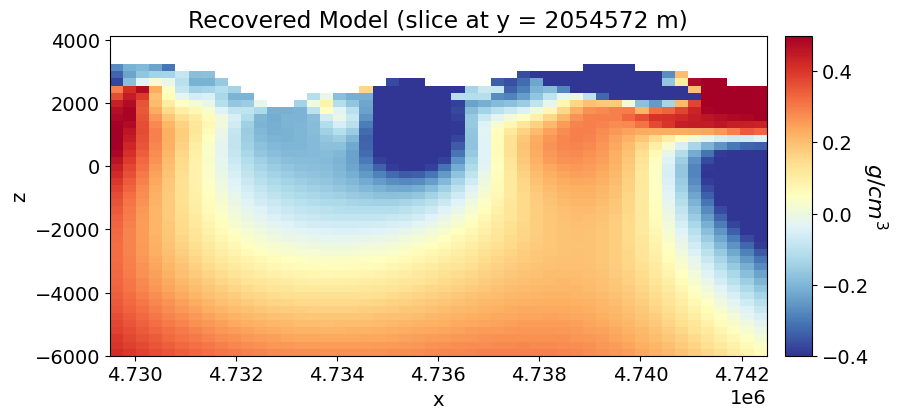

In [ ]:
slice_loc = 2054572  #@param {type:"number"}
slice_normal = "y"   #@param ["x","y","z"]

fig = plt.figure(figsize=(9, 4))
ax1 = fig.add_axes([0.1, 0.1, 0.73, 0.8])

norm = mpl.colors.Normalize(vmin=np.min(recovered_tensor_model), vmax=np.max(recovered_tensor_model))

mesh.plot_slice(
    tensor_plotting_map * recovered_tensor_model,
    normal=slice_normal,
    ax=ax1,
    slice_loc=slice_loc,
    grid=False,
    pcolor_opts={"cmap": mpl.cm.RdYlBu_r, "norm": norm},
)
ax1.set_title(f"Recovered Model (slice at {slice_normal} = {slice_loc} m)")

ax2 = fig.add_axes([0.85, 0.1, 0.03, 0.8])
cbar = mpl.colorbar.ColorbarBase(ax2, norm=norm, orientation="vertical", cmap=mpl.cm.RdYlBu_r)
cbar.set_label("$g/cm^3$", rotation=270, labelpad=15, size=16)

plt.show()

## 14. Ajuste en el espacio de datos: predicho, observado y residual

Una inversión “buena” no solo entrega un modelo: también debe **reproducir los datos**.

Mostramos:
- mapa de datos **predichos** por el modelo invertido,
- mapa de datos **observados**,
- mapa del **residual** $d_{obs}-d_{pred}$.

Usamos:
- misma escala para observado/predicho (comparación justa),
- escala simétrica para residuales (resalta patrones de error).


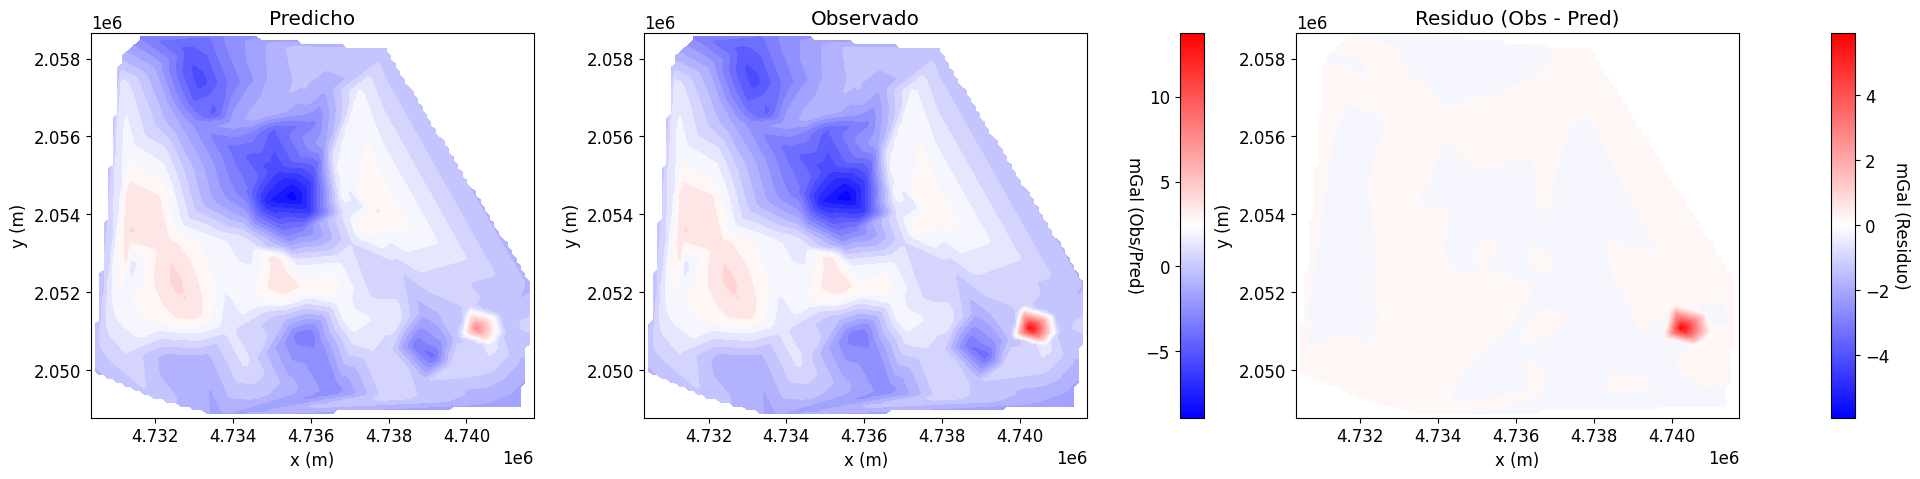

In [ ]:
# Convención de signo para dpred
DPRED_FLIP_SIGN = True  #@param {type:"boolean"}

dpred = (-inv_prob_L2.dpred) if DPRED_FLIP_SIGN else inv_prob_L2.dpred
res = dobs - dpred

vmin = np.nanmin([np.nanmin(dpred), np.nanmin(dobs)])
vmax = np.nanmax([np.nanmax(dpred), np.nanmax(dobs)])
clim = [vmin, vmax]

rmax = np.nanmax(np.abs(res))
rclim = [-rmax, rmax]

mpl.rcParams.update({"font.size": 12})

fig = plt.figure(figsize=(23, 5))
gs = fig.add_gridspec(1, 5, width_ratios=[1, 1, 0.05, 1, 0.05], wspace=0.25)

ax_pred  = fig.add_subplot(gs[0, 0])
ax_obs   = fig.add_subplot(gs[0, 1])
cax_main = fig.add_subplot(gs[0, 2])
ax_res   = fig.add_subplot(gs[0, 3])
cax_res  = fig.add_subplot(gs[0, 4])

plot2Ddata(receiver_locations, dpred, ax=ax_pred, ncontour=30, clim=clim, contourOpts={"cmap": "bwr"})
ax_pred.set_title("Predicho"); ax_pred.set_xlabel("x (m)"); ax_pred.set_ylabel("y (m)")

plot2Ddata(receiver_locations, dobs, ax=ax_obs, ncontour=30, clim=clim, contourOpts={"cmap": "bwr"})
ax_obs.set_title("Observado"); ax_obs.set_xlabel("x (m)"); ax_obs.set_ylabel("y (m)")

plot2Ddata(receiver_locations, res, ax=ax_res, ncontour=30, clim=rclim, contourOpts={"cmap": "bwr"})
ax_res.set_title("Residuo (Obs - Pred)"); ax_res.set_xlabel("x (m)"); ax_res.set_ylabel("y (m)")

norm1 = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
cb1 = mpl.colorbar.ColorbarBase(cax_main, norm=norm1, orientation="vertical", cmap=mpl.cm.bwr)
cb1.set_label("mGal (Obs/Pred)", rotation=270, labelpad=15, size=12)
cax_main.yaxis.set_ticks_position("left")
cax_main.yaxis.set_label_position("left")

norm2 = mpl.colors.Normalize(vmin=rclim[0], vmax=rclim[1])
cb2 = mpl.colorbar.ColorbarBase(cax_res, norm=norm2, orientation="vertical", cmap=mpl.cm.bwr)
cb2.set_label("mGal (Residuo)", rotation=270, labelpad=15, size=12)
cax_res.yaxis.set_ticks_position("right")
cax_res.yaxis.set_label_position("right")

plt.show()

## 15. Métricas de ajuste (cuantitativas)

Complementamos las figuras con métricas:

- **RMSE / MAE** en mGal,  
- **$\chi^2_{red}$** basado en $\phi_d / N$ (ideal $\sim 1$).

Estas métricas ayudan a decidir si:

- el modelo explica el dato dentro del ruido,  
- o si falta regularización / pesos / revisión de $\sigma$ y signos.


In [ ]:
DPRED_FLIP_SIGN = True  #@param {type:"boolean"}

dpred = (-inv_prob_L2.dpred) if DPRED_FLIP_SIGN else inv_prob_L2.dpred
res = dobs - dpred
N = res.size

rmse = np.sqrt(np.mean(res**2))
mae  = np.mean(np.abs(res))
rmse_w = np.sqrt(np.mean((res / sigma)**2))

phi_d = inv_prob_L2.dmisfit(recovered_tensor_model)
chi2_red = phi_d / N

print("\n===== MÉTRICAS DE AJUSTE =====")
print(f"RMSE              : {rmse:.4f} mGal")
print(f"MAE               : {mae:.4f} mGal")
print(f"Chi^2             : {chi2_red:.4f}")
print("================================")


===== MÉTRICAS DE AJUSTE =====
RMSE              : 0.5117 mGal
MAE               : 0.0789 mGal
Chi^2             : 2.8984


## 16. Exportación del modelo a VTI (ParaView / PyVista)

Finalmente, construimos un volumen 3D compatible con visualizadores:

- inyectamos celdas activas en el mallado completo (NaN en inactivas),
- convertimos a `ImageData` con `spacing` y `origin` correctos,
- guardamos como `Modelo_invertido.vti`.

Esto permite explorar el modelo en 3D (isosuperficies, slices interactivos, volumen).

In [ ]:
OUT_VTI = "Modelo_invertido.vti"  #@param {type:"string"}
FIELD_NAME = "Contraste de densidad"           #@param {type:"string"}

m_full = mkvc(
    maps.InjectActiveCells(mesh, active_tensor_cells, np.nan) * mkvc(recovered_tensor_model)
).astype(np.float32)

nx, ny, nz = mesh.shape_cells
hx, hy, hz = mesh.h

grid = pv.ImageData(
    dimensions=(nx + 1, ny + 1, nz + 1),
    spacing=(float(hx[0]), float(hy[0]), float(hz[0])),
    origin=tuple(mesh.x0),
)

grid.cell_data[FIELD_NAME] = m_full.reshape((nx, ny, nz), order="F").ravel(order="F")
grid.save(OUT_VTI)
print(f"Guardado: {OUT_VTI}")

Guardado: Modelo_invertido.vti
